In [835]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv("C:\\Users\\testi\\OneDrive\\Desktop\\data\\car details v4.csv")
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [836]:
data.shape

(2059, 20)

In [837]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

In [838]:
round(data.describe())

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2059.0,2059.0,2059.0,1995.0,1995.0,1995.0,1995.0,1946.0
mean,1702992.0,2016.0,54225.0,4281.0,1768.0,1592.0,5.0,52.0
std,2419881.0,3.0,57362.0,442.0,135.0,136.0,1.0,15.0
min,49000.0,1988.0,0.0,3099.0,1475.0,1165.0,2.0,15.0
25%,484999.0,2014.0,29000.0,3985.0,1695.0,1485.0,5.0,41.0
50%,825000.0,2017.0,50000.0,4370.0,1770.0,1545.0,5.0,50.0
75%,1925000.0,2019.0,72000.0,4629.0,1832.0,1675.0,5.0,60.0
max,35000000.0,2022.0,2000000.0,5569.0,2220.0,1995.0,8.0,105.0


In [839]:
data.isna().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [840]:
missing_cols = data.columns[data.isna().sum() >0]
missing_cols

Index(['Engine', 'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width',
       'Height', 'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='str')

In [841]:
def handle_missing_values(df, missing_cols):
    for col in missing_cols:
        if(df[col].dtype == "int" or df[col].dtype == "float") :
            df[col] = df[col].fillna(df[col].median())
        elif(df[col].dtype == "str") :
            df[col] = df[col].fillna(df[col].mode()[0])
    return df;

In [842]:
data = handle_missing_values(data, missing_cols)


In [843]:
data.isna().sum()

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64

In [844]:
#handle duplicates and missing values if any.
data.duplicated().sum()


np.int64(0)

In [845]:
for col in data.columns:
    print(col, data[col].unique())
    print("---------------\n")

Make <StringArray>
[        'Honda', 'Maruti Suzuki',       'Hyundai',        'Toyota',
 'Mercedes-Benz',           'BMW',         'Skoda',        'Nissan',
       'Renault',          'Tata',    'Volkswagen',          'Ford',
          'Audi',      'Mahindra',            'MG',          'Jeep',
       'Porsche',           'Kia',    'Land Rover',         'Volvo',
      'Maserati',        'Jaguar',         'Isuzu',          'Fiat',
          'MINI',       'Ferrari',    'Mitsubishi',        'Datsun',
   'Lamborghini',     'Chevrolet',     'Ssangyong',   'Rolls-Royce',
         'Lexus']
Length: 33, dtype: str
---------------

Model <StringArray>
[                    'Amaze 1.2 VX i-VTEC',
                         'Swift DZire VDI',
                    'i10 Magna 1.2 Kappa2',
                                'Glanza G',
         'Innova 2.4 VX 7 STR [2016-2020]',
                                'Ciaz ZXi',
                    'CLA 200 Petrol Sport',
                    'X1 xDrive20d M Sport',

In [846]:
def clean_data(value):
    value = value.split(' ')[0]
    value = value.strip()
    if value == '':
        value = 0
    return float(value)

In [847]:
#separate numeric values from object 
data['Max Power'] = data["Max Power"].str.extract(r'(\d+\.?\d*)')
data['Max Torque'] = data['Max Torque'].str.extract(r'(\d+\.?\d*)')
data["Engine"] = data['Engine'].str.extract(r'(\d+\.?\d*)')
data["Max Power"] = pd.to_numeric(data["Max Power"])
data["Max Torque"] = pd.to_numeric(data["Max Torque"])
data["Engine"] = pd.to_numeric(data["Engine"])

In [848]:
data

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,Mahindra,XUV500 W8 [2015-2017],850000,2016,90300,Diesel,Manual,Surat,White,First,Individual,2179,138.0,330.0000,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,Hyundai,Eon D-Lite +,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,Individual,814,55.0,75.0000,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,Ford,Figo Duratec Petrol ZXI 1.2,240000,2013,73000,Petrol,Manual,Thane,Silver,First,Individual,1196,70.0,102.0000,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,BMW,5-Series 520d Luxury Line [2017-2019],4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,Individual,1995,188.0,400.0000,RWD,4936.0,1868.0,1479.0,5.0,65.0


In [849]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              2059 non-null   int64  
 12  Max Power           2059 non-null   float64
 13  Max Torque          2059 non-null   float64
 14  Drivetrain          2059 non-null   str    
 15  Length              2059 non-null   float64
 16  Width            

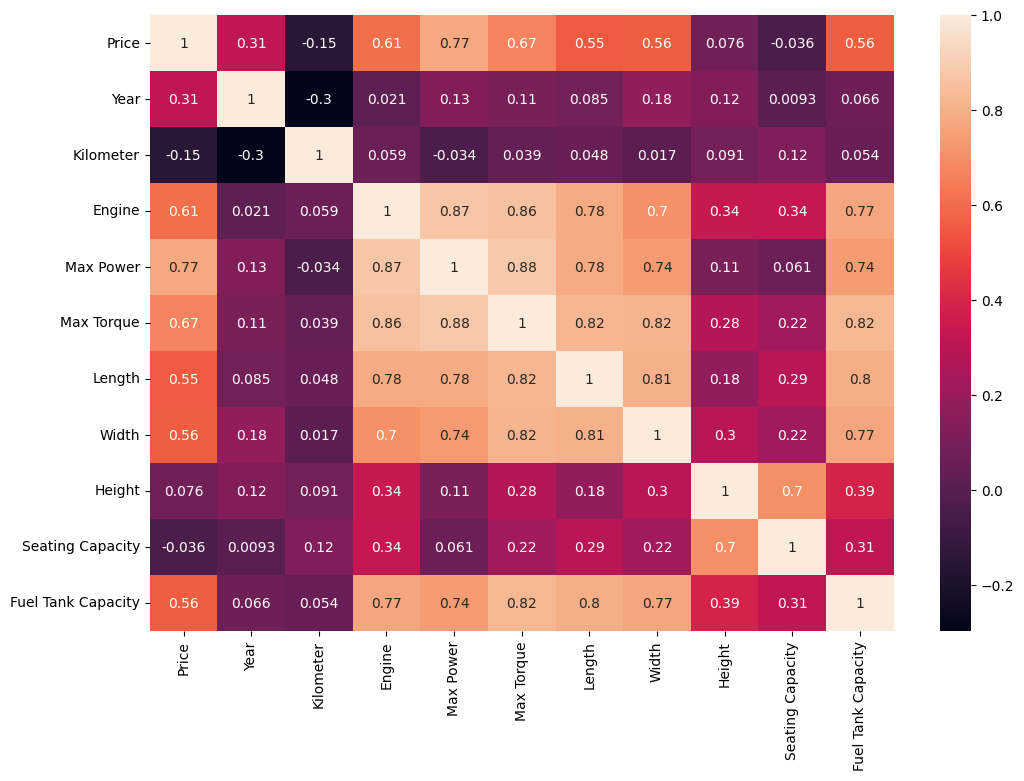

In [850]:
plt.figure(figsize=(12,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

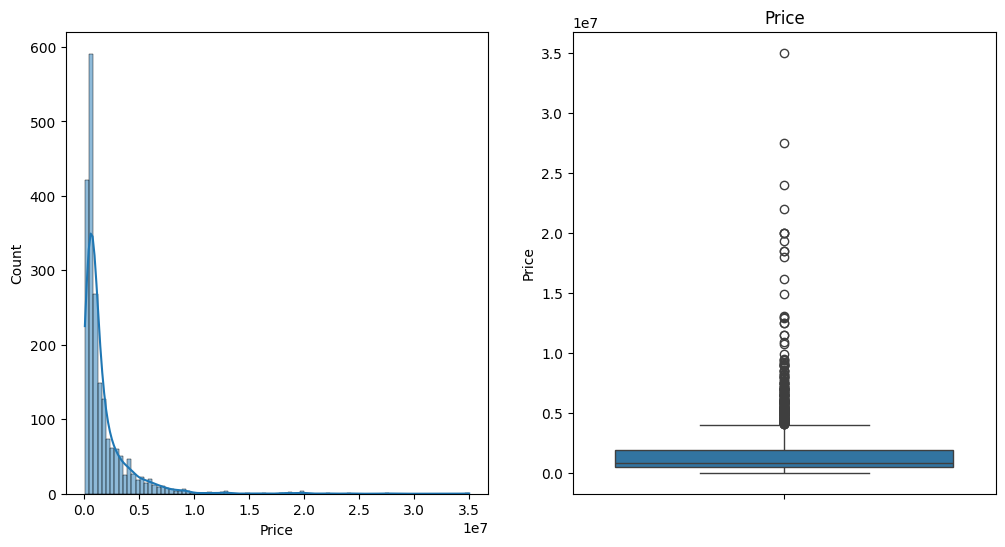

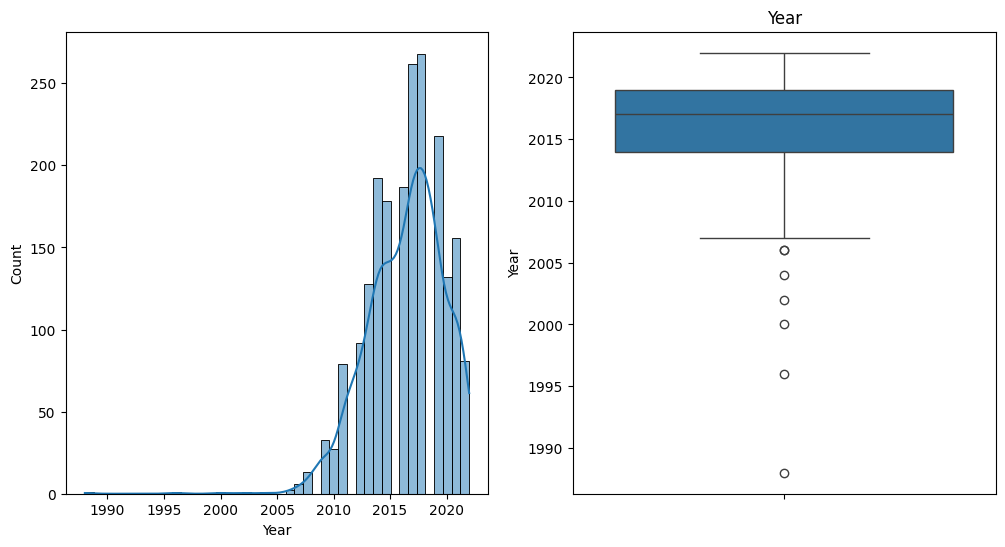

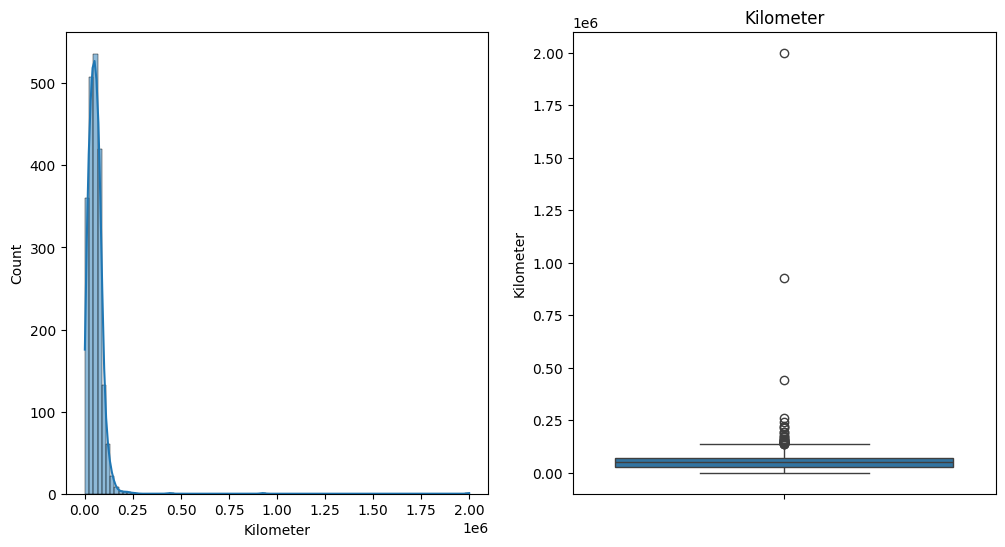

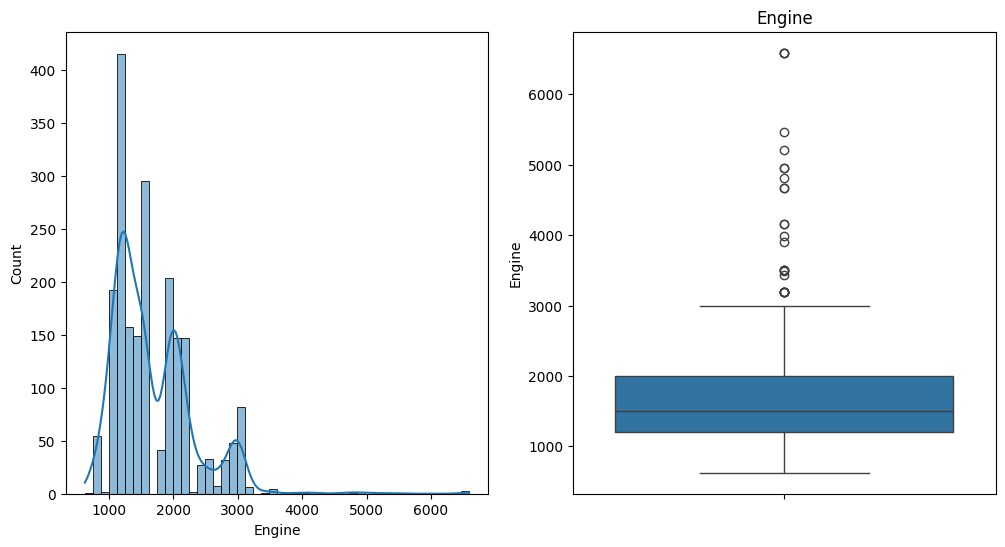

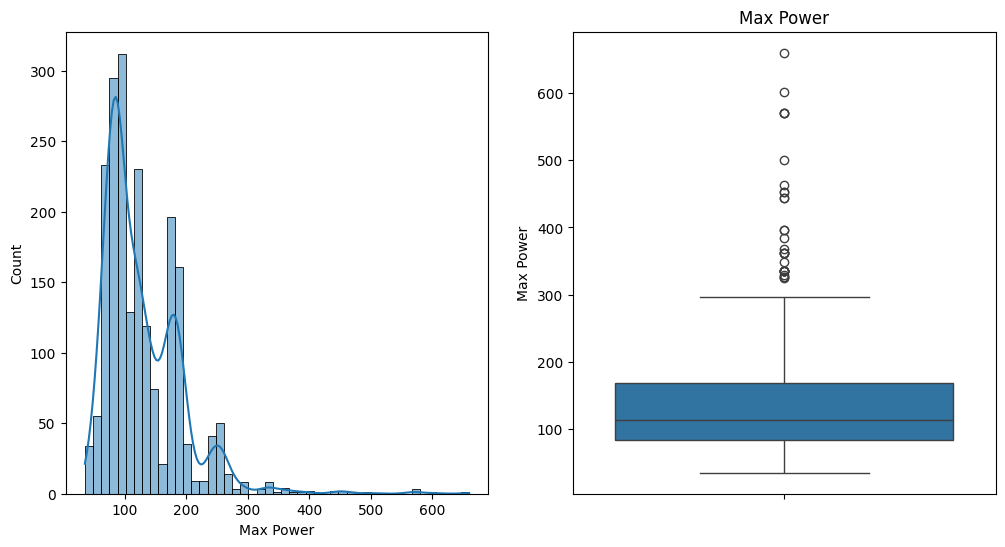

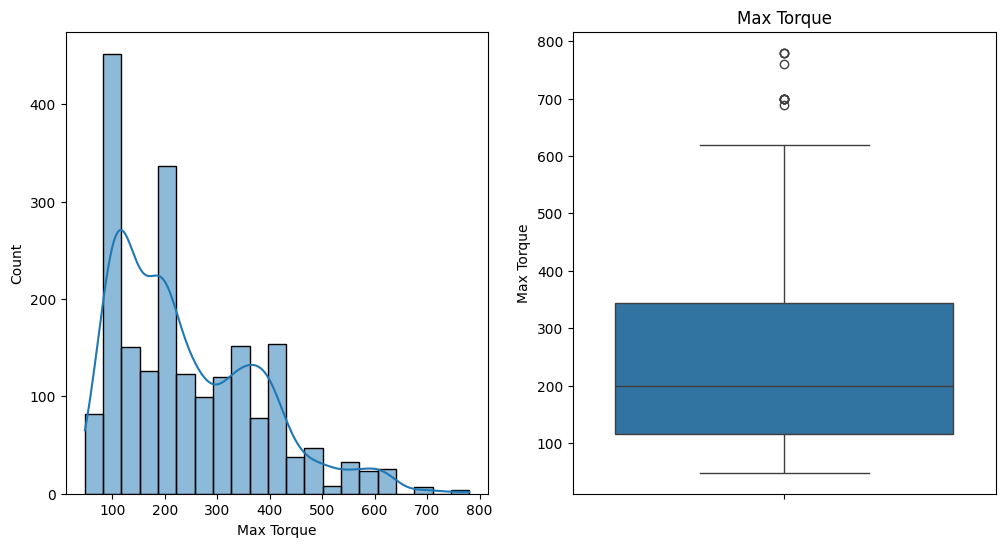

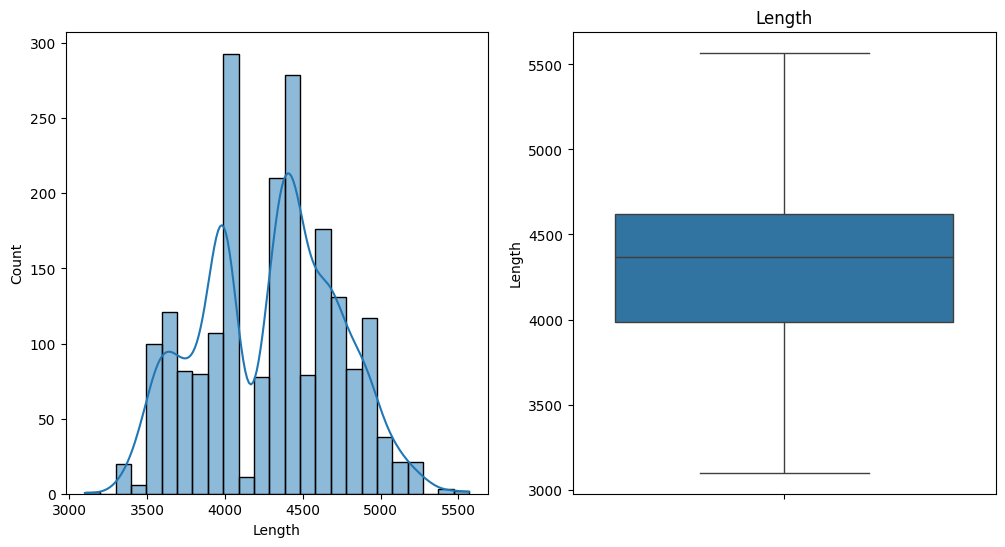

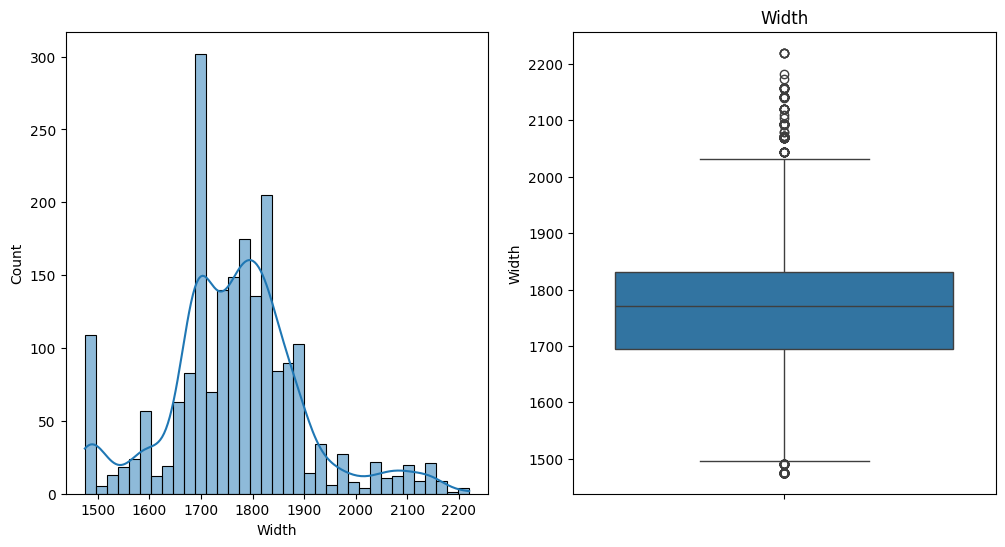

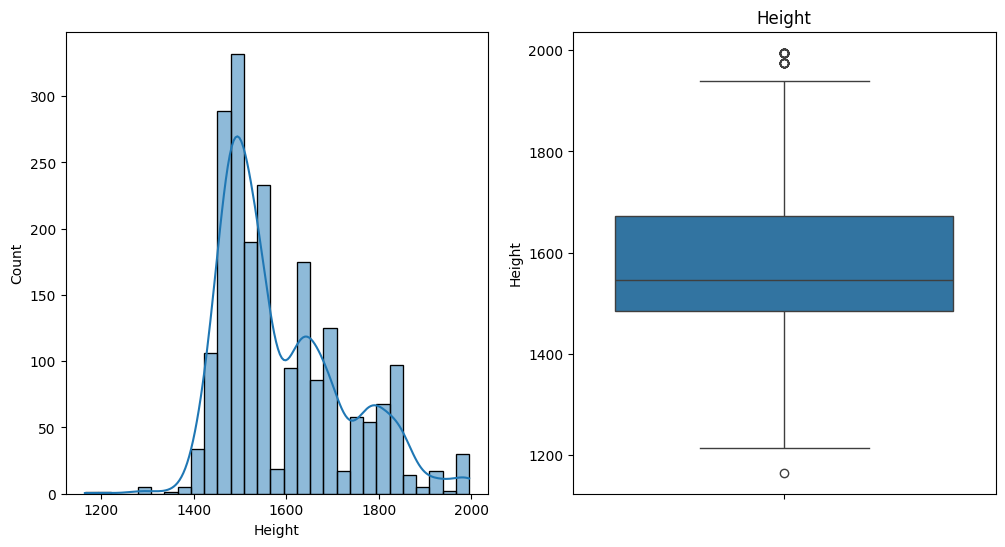

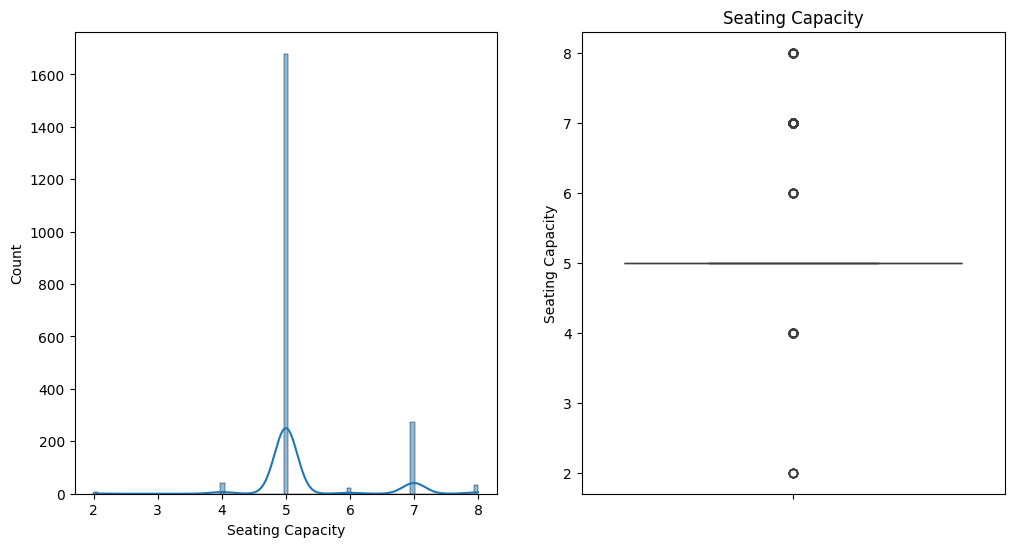

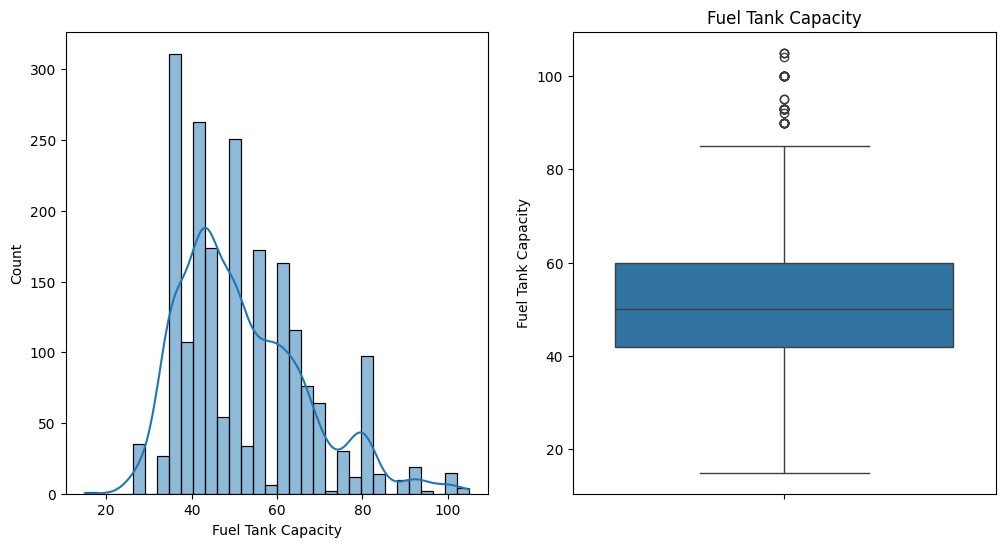

In [851]:
num_columns = data.select_dtypes("number")
for col in num_columns:
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    sns.histplot(data[col], kde=True)
    plt.subplot(1,2,2)
    sns.boxplot(data[col])
    plt.title(col)
    plt.show(col)

In [852]:
data[data["Max Power"] == 660]

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
483,Ferrari,488 GTB,35000000,2018,9500,Petrol,Automatic,Delhi,Black,First,Individual,3902,660.0,760.0,RWD,4568.0,1952.0,1213.0,2.0,78.0


In [853]:
#Encode categorical variables appropriately.
cat_columns = data.select_dtypes("str")
model_target_mean = data.groupby('Model')['Price'].mean() #.333333
make_target_mean = data.groupby('Make')['Price'].mean() #.333333
location_target_mean = data.groupby('Location')['Price'].mean() #.333333

# Map Model to mean value
data['Model'] = data['Model'].map(model_target_mean)
data['Make'] = data['Make'].map(make_target_mean)
data['Location'] = data['Location'].map(location_target_mean)

In [854]:
data

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,6.221076e+05,5.050000e+05,505000,2017,87150,Petrol,Manual,1.977764e+06,Grey,First,Corporate,1198,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,5.348000e+05,4.147142e+05,450000,2014,75000,Diesel,Manual,1.475745e+06,White,Second,Individual,1248,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,7.232635e+05,2.931250e+05,220000,2011,67000,Petrol,Manual,9.643333e+05,Maroon,First,Individual,1197,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,1.729545e+06,7.622500e+05,799000,2019,37500,Petrol,Manual,7.424000e+05,Red,First,Individual,1197,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,1.729545e+06,1.927200e+06,1950000,2018,69000,Diesel,Manual,1.721570e+06,Grey,First,Individual,2393,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,1.083479e+06,8.500000e+05,850000,2016,90300,Diesel,Manual,2.980400e+06,White,First,Individual,2179,138.0,330.0000,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,7.232635e+05,2.625000e+05,275000,2014,83000,Petrol,Manual,1.507257e+06,White,Second,Individual,814,55.0,75.0000,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,1.474625e+06,2.400000e+05,240000,2013,73000,Petrol,Manual,1.149000e+06,Silver,First,Individual,1196,70.0,102.0000,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,3.768967e+06,4.337900e+06,4290000,2018,60474,Diesel,Automatic,1.385207e+06,White,First,Individual,1995,188.0,400.0000,RWD,4936.0,1868.0,1479.0,5.0,65.0


In [855]:
data.Transmission.unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [856]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Transmission'] =le.fit_transform(data["Transmission"])

In [857]:
data

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,6.221076e+05,5.050000e+05,505000,2017,87150,Petrol,1,1.977764e+06,Grey,First,Corporate,1198,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,5.348000e+05,4.147142e+05,450000,2014,75000,Diesel,1,1.475745e+06,White,Second,Individual,1248,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,7.232635e+05,2.931250e+05,220000,2011,67000,Petrol,1,9.643333e+05,Maroon,First,Individual,1197,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,1.729545e+06,7.622500e+05,799000,2019,37500,Petrol,1,7.424000e+05,Red,First,Individual,1197,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,1.729545e+06,1.927200e+06,1950000,2018,69000,Diesel,1,1.721570e+06,Grey,First,Individual,2393,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,1.083479e+06,8.500000e+05,850000,2016,90300,Diesel,1,2.980400e+06,White,First,Individual,2179,138.0,330.0000,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,7.232635e+05,2.625000e+05,275000,2014,83000,Petrol,1,1.507257e+06,White,Second,Individual,814,55.0,75.0000,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,1.474625e+06,2.400000e+05,240000,2013,73000,Petrol,1,1.149000e+06,Silver,First,Individual,1196,70.0,102.0000,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,3.768967e+06,4.337900e+06,4290000,2018,60474,Diesel,0,1.385207e+06,White,First,Individual,1995,188.0,400.0000,RWD,4936.0,1868.0,1479.0,5.0,65.0


In [858]:
data["Fuel Type"].unique()

<StringArray>
[      'Petrol',       'Diesel',          'CNG',          'LPG',
     'Electric',    'CNG + CNG',       'Hybrid', 'Petrol + CNG',
 'Petrol + LPG']
Length: 9, dtype: str

In [859]:
data["Seller Type"].unique()

<StringArray>
['Corporate', 'Individual', 'Commercial Registration']
Length: 3, dtype: str

In [860]:
data = pd.get_dummies(data, columns=['Fuel Type', 'Owner', 'Drivetrain', 'Color', 'Seller Type'],dtype=int,drop_first = True)


In [861]:
data

,Make,Model,Price,Year,Kilometer,Transmission,Location,Engine,Max Power,Max Torque,...,Color_Orange,Color_Others,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_White,Color_Yellow,Seller Type_Corporate,Seller Type_Individual
0,6.221076e+05,5.050000e+05,505000,2017,87150,1,1.977764e+06,1198,87.0,109.0000,...,0,0,0,0,0,0,0,0,1,0
1,5.348000e+05,4.147142e+05,450000,2014,75000,1,1.475745e+06,1248,74.0,190.0000,...,0,0,0,0,0,0,1,0,0,1
2,7.232635e+05,2.931250e+05,220000,2011,67000,1,9.643333e+05,1197,79.0,112.7619,...,0,0,0,0,0,0,0,0,0,1
3,1.729545e+06,7.622500e+05,799000,2019,37500,1,7.424000e+05,1197,82.0,113.0000,...,0,0,0,0,1,0,0,0,0,1
4,1.729545e+06,1.927200e+06,1950000,2018,69000,1,1.721570e+06,2393,148.0,343.0000,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,1.083479e+06,8.500000e+05,850000,2016,90300,1,2.980400e+06,2179,138.0,330.0000,...,0,0,0,0,0,0,1,0,0,1
2055,7.232635e+05,2.625000e+05,275000,2014,83000,1,1.507257e+06,814,55.0,75.0000,...,0,0,0,0,0,0,1,0,0,1
2056,1.474625e+06,2.400000e+05,240000,2013,73000,1,1.149000e+06,1196,70.0,102.0000,...,0,0,0,0,0,1,0,0,0,1
2057,3.768967e+06,4.337900e+06,4290000,2018,60474,0,1.385207e+06,1995,188.0,400.0000,...,0,0,0,0,0,0,1,0,0,1


In [862]:
# Normalize or scale features if necessary.


In [863]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ["Make","Model","Kilometer","Year","Engine","Max Power","Max Torque"]
data[scale_cols] = scaler.fit_transform(data[scale_cols])

In [864]:
data

,Make,Model,Price,Year,Kilometer,Transmission,Location,Engine,Max Power,Max Torque,...,Color_Orange,Color_Others,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_White,Color_Yellow,Seller Type_Corporate,Seller Type_Individual
0,-0.567414,-0.500187,505000,0.170858,0.574133,1,1.977764e+06,-0.744814,-0.638540,-0.979049,...,0,0,0,0,0,0,0,0,1,0
1,-0.613246,-0.537883,450000,-0.721270,0.362268,1,1.475745e+06,-0.666465,-0.840837,-0.391922,...,0,0,0,0,0,0,1,0,0,1
2,-0.514312,-0.588650,220000,-1.613398,0.222769,1,9.643333e+05,-0.746381,-0.763030,-0.951781,...,0,0,0,0,0,0,0,0,0,1
3,0.013939,-0.392780,799000,0.765609,-0.291637,1,7.424000e+05,-0.746381,-0.716346,-0.950055,...,0,0,0,0,1,0,0,0,0,1
4,0.013939,0.093612,1950000,0.468234,0.257644,1,1.721570e+06,1.127717,0.310699,0.717096,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,-0.325215,-0.356142,850000,-0.126518,0.629061,1,2.980400e+06,0.792385,0.155086,0.622865,...,0,0,0,0,0,0,1,0,0,1
2055,-0.514312,-0.601436,275000,-0.721270,0.501768,1,1.507257e+06,-1.346531,-1.136501,-1.225498,...,0,0,0,0,0,0,1,0,0,1
2056,-0.119882,-0.610830,240000,-1.018646,0.327393,1,1.149000e+06,-0.747948,-0.903082,-1.029788,...,0,0,0,0,0,1,0,0,0,1
2057,1.084541,1.100131,4290000,0.468234,0.108972,0,1.385207e+06,0.504062,0.933151,1.130259,...,0,0,0,0,0,0,1,0,0,1


In [865]:
data[scale_cols].skew()

Make           5.386461
Model          4.994393
Kilometer     20.980719
Year          -0.840685
Engine         1.802402
Max Power      2.129423
Max Torque     0.929859
dtype: float64

In [866]:
# Model Development:
# Split the data into training and testing sets.
# Train a regression model (e.g., Linear Regression) to predict charges.
x= data.drop("Price", axis=1)
y = data["Price"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test =train_test_split(x,y, random_state=42,train_size=.8,test_size=.2)
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](47,)","[616025.09,791212.49,532921.97,..., 3632.38, 18150.36,-18970.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](47,)","['Make','Model','Year',...,'Color_Yellow','Seller Type_Corporate', 'Seller Type_Individual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.241e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,47
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [867]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "Actual (₹)": y_test.values,
    "Predicted (₹)": y_pred.astype(int)
})
results

,Actual (₹),Predicted (₹)
0,4800000,5352852
1,825000,632463
2,695000,188093
3,950000,1433922
4,819999,626598
...,...,...
407,275000,-838705
408,1550000,2918694
409,5590000,4316810
410,325000,164926


In [868]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Regression metrics
r2 = r2_score(y_test, y_pred)*100
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR² Score: {r2:.4f}")
print(f"Mean Absolute Error: ₹{int(mae):,}")
print(f"Mean Squared Error: ₹{int(rmse):,}")


R² Score: 89.6872
Mean Absolute Error: ₹548,844
Mean Squared Error: ₹848,811


In [869]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

In [870]:
train_score,test_score

(0.8466084669095666, 0.8968721692460931)